In [31]:
import cv2 as cv
import pytesseract
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

Aprendendo a Usar Libs de CV em python
Pillow, OpenCV

# Abrir Imagens

In [32]:
img_path = "../../data/raw/page_01.jpg"
img = cv.imread(img_path)

In [33]:
def display(im_path):
    dpi = 80
    im_data = plt.imread(im_path)

    height, width  = im_data.shape[:2]
    
    # What size does the figure need to be in inches to fit the image?
    figsize = width / float(dpi), height / float(dpi)

    # Create a figure of the right size with one axes that takes up the full figure
    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    # Hide spines, ticks, etc.
    ax.axis('off')

    # Display the image.
    ax.imshow(im_data, cmap='gray')

    plt.show()

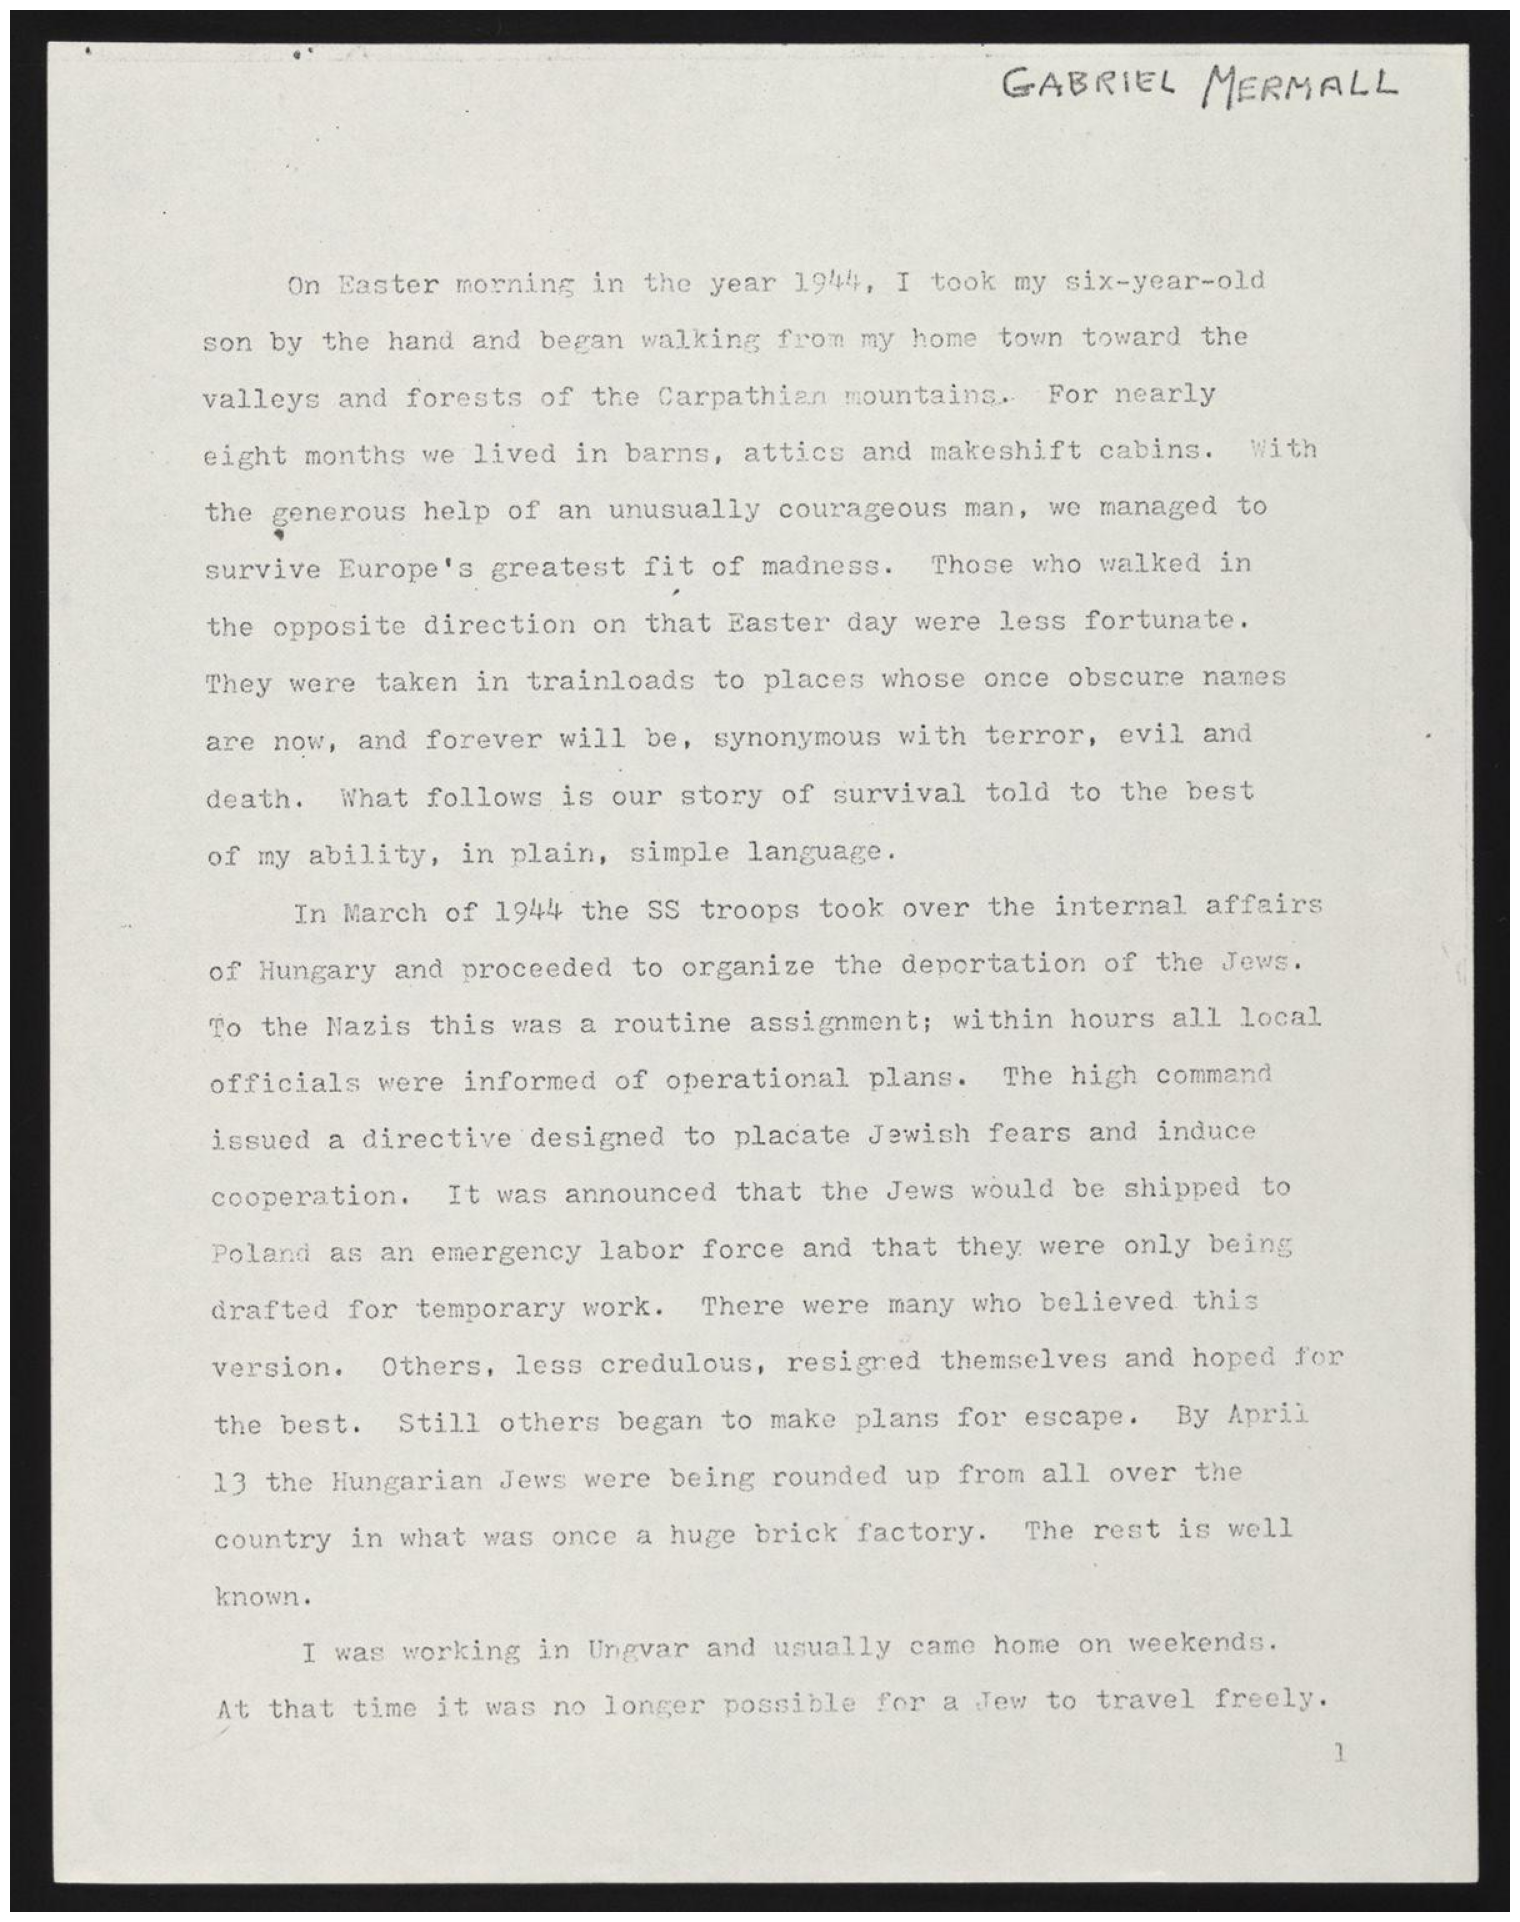

In [34]:
display(img_path)

# Invertendo Imagens (Preto para Branco)

In [35]:
iverted_img = cv.bitwise_not(img)
cv.imwrite("../../data/process/test_inverted.png", iverted_img)

True

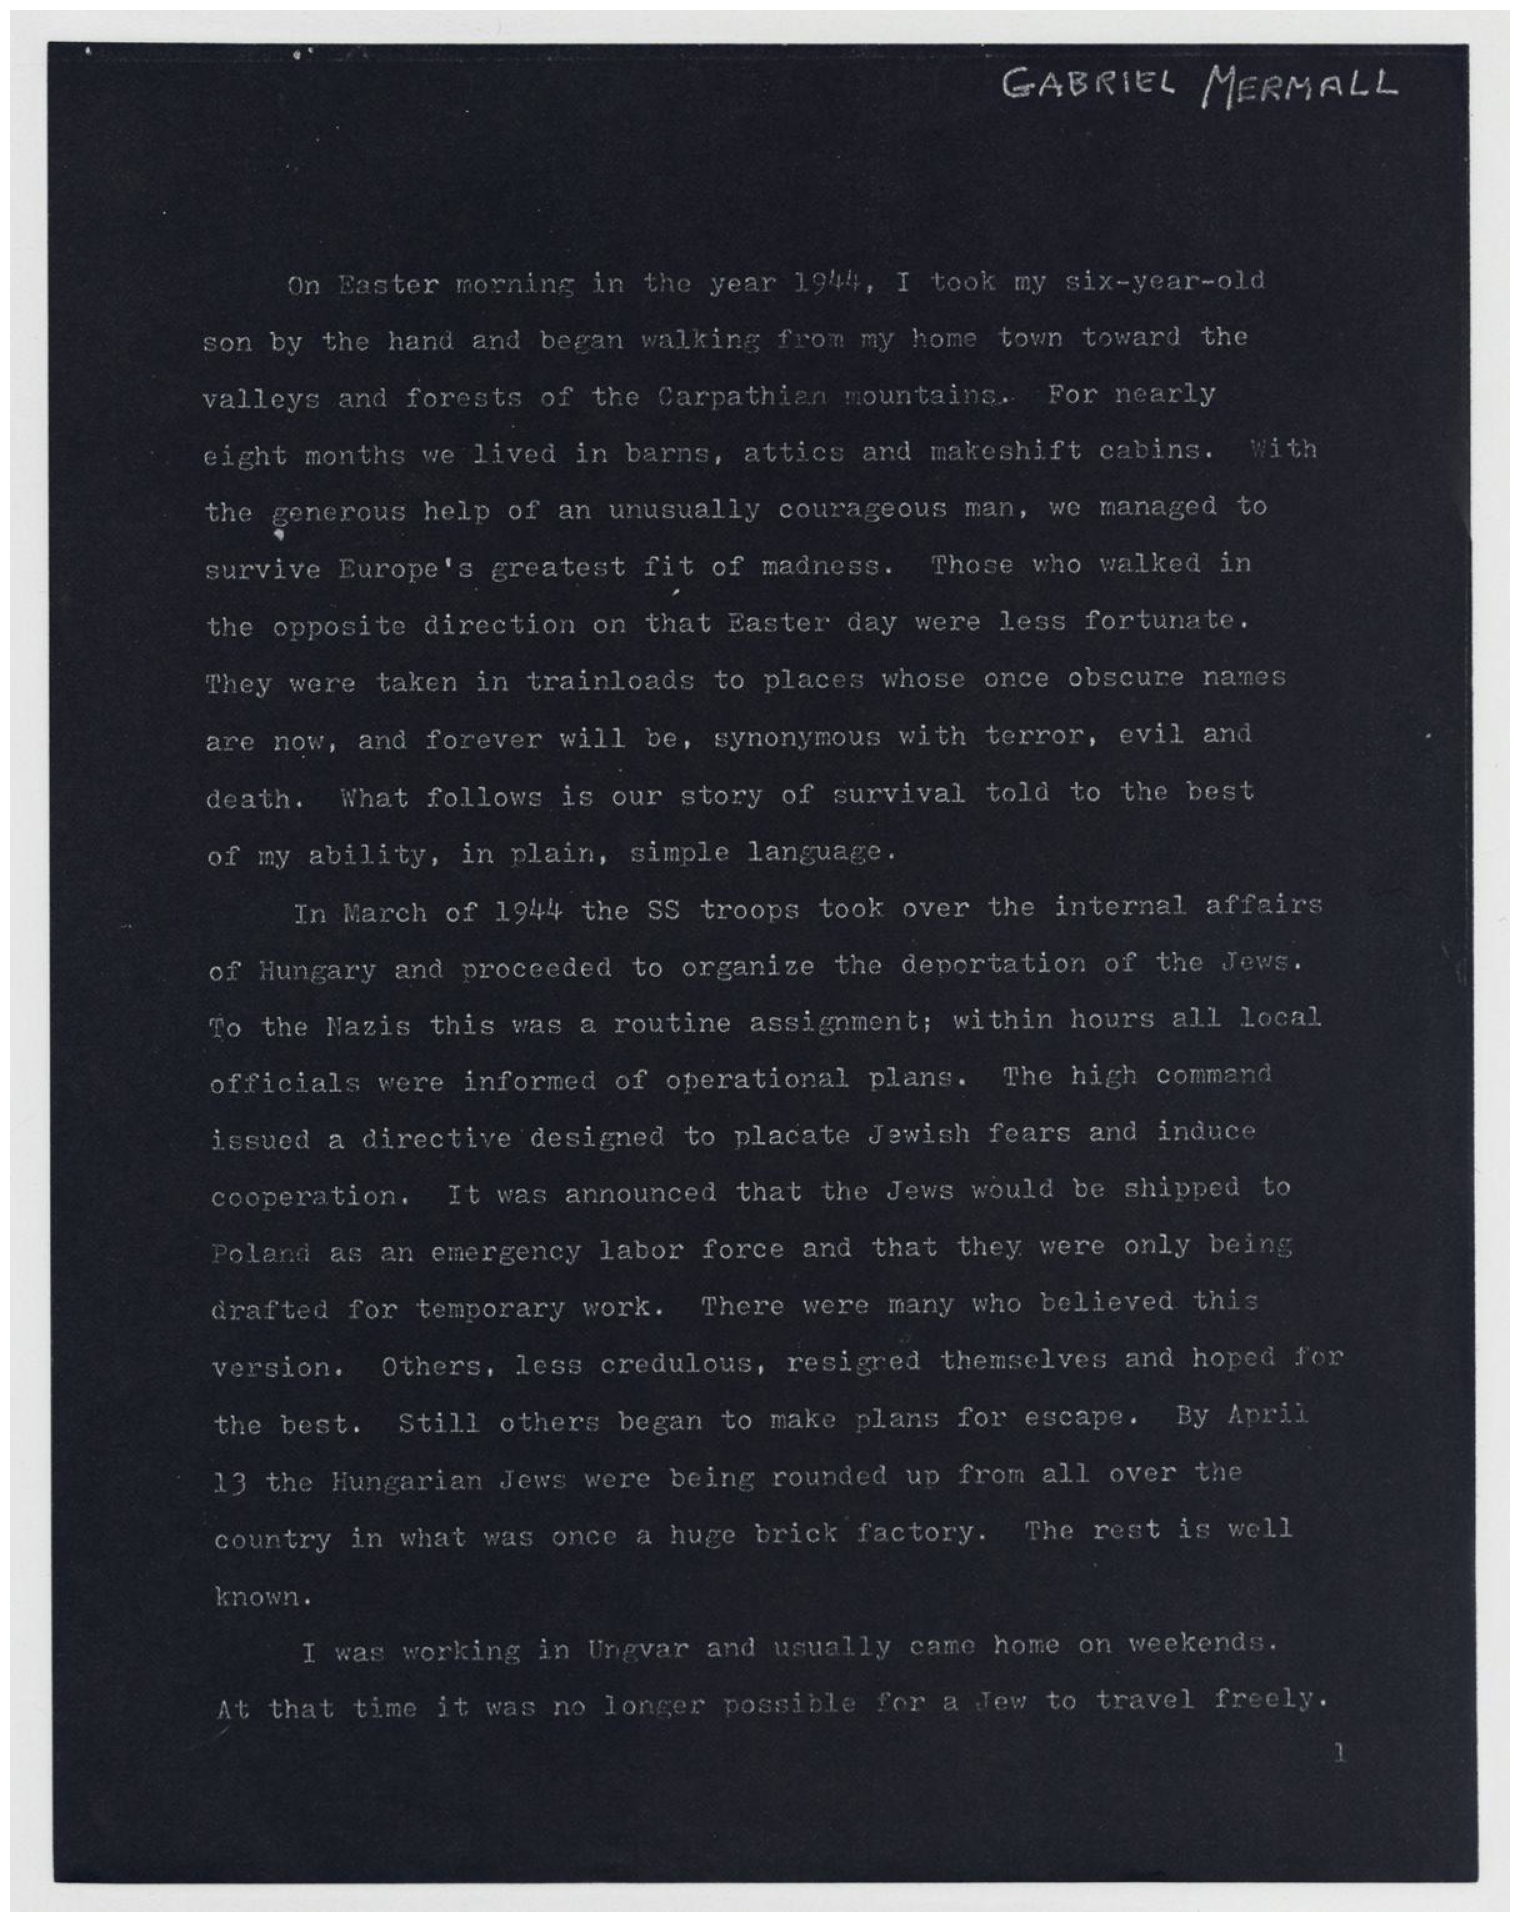

In [36]:
display("../../data/process/test_inverted.png")

# Redimensionamento

# Binarização

In [41]:
def grayscale(image):
    return cv.cvtColor(image, cv.COLOR_BGR2GRAY)

In [42]:
gray_img = grayscale(img)
cv.imwrite("../../data/process/test_gray.png", gray_img)

True

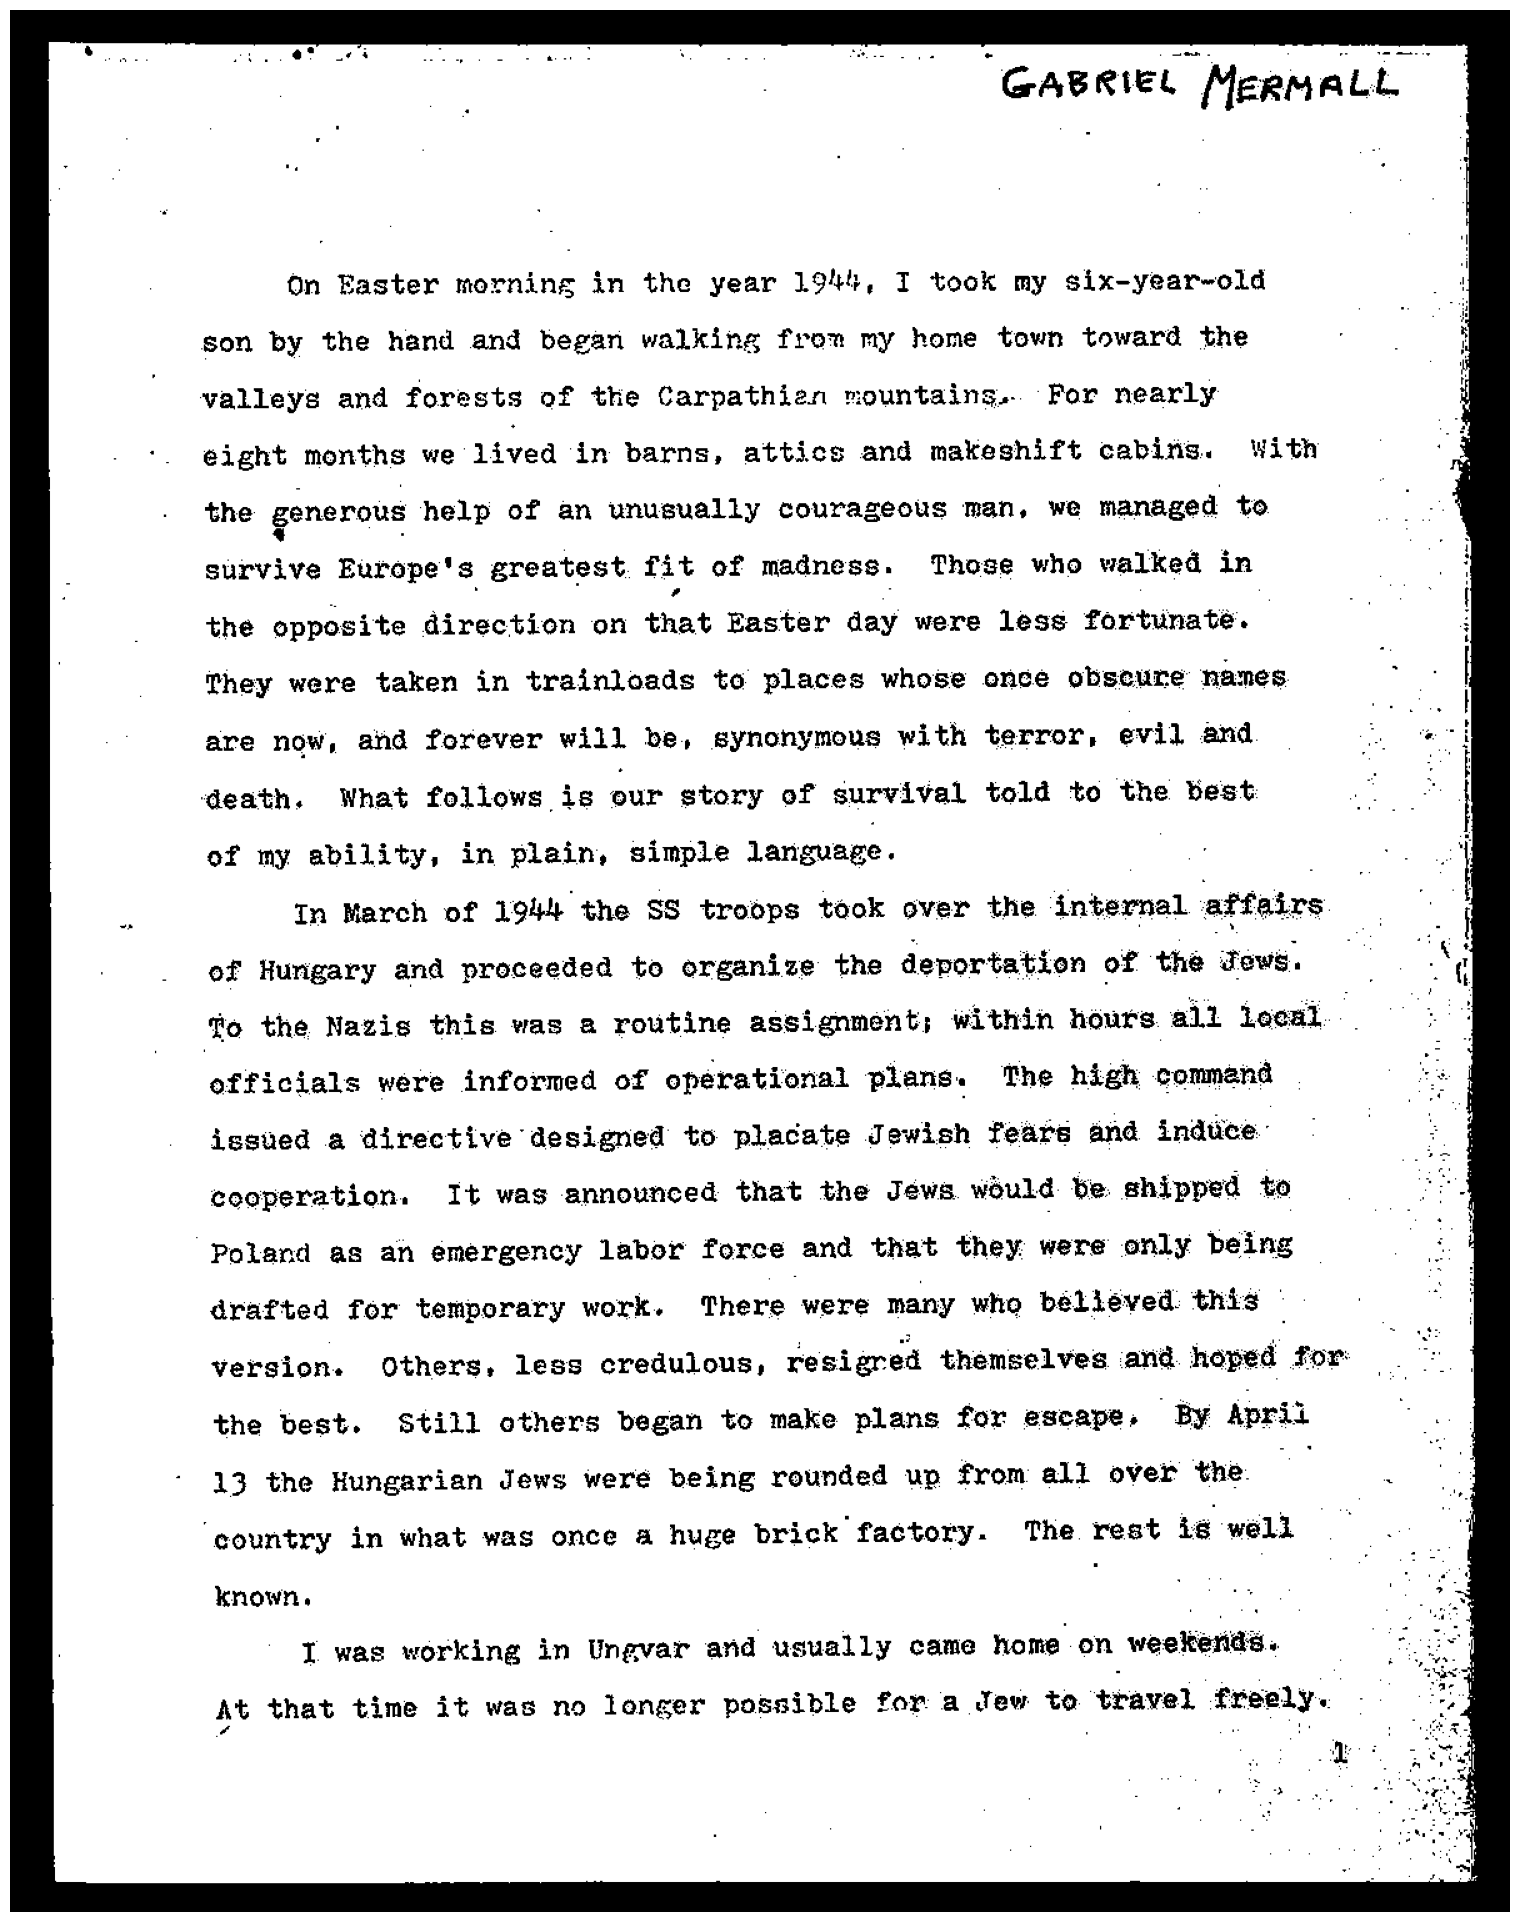

In [45]:
thresh, img_bw = cv.threshold(gray_img, 210, 230, cv.THRESH_BINARY)

cv.imwrite("../../data/process/test_bw.png", img_bw)

display("../../data/process/test_bw.png")

# Remoção de Ruido

In [ ]:
def nose_removal(image):
    kernel = np.ones((1,1),np.uint8)
    image = cv.dilate(image, kernel, iterations = 1)
    kernel = np.ones((1,1),np.uint8)
    image = cv.erode(image, kernel, iterations = 1)
    image = cv.morphologyEx(image, cv.MORPH_CLOSE, kernel)
    image = cv.medianBlur(image, 3)
    return image

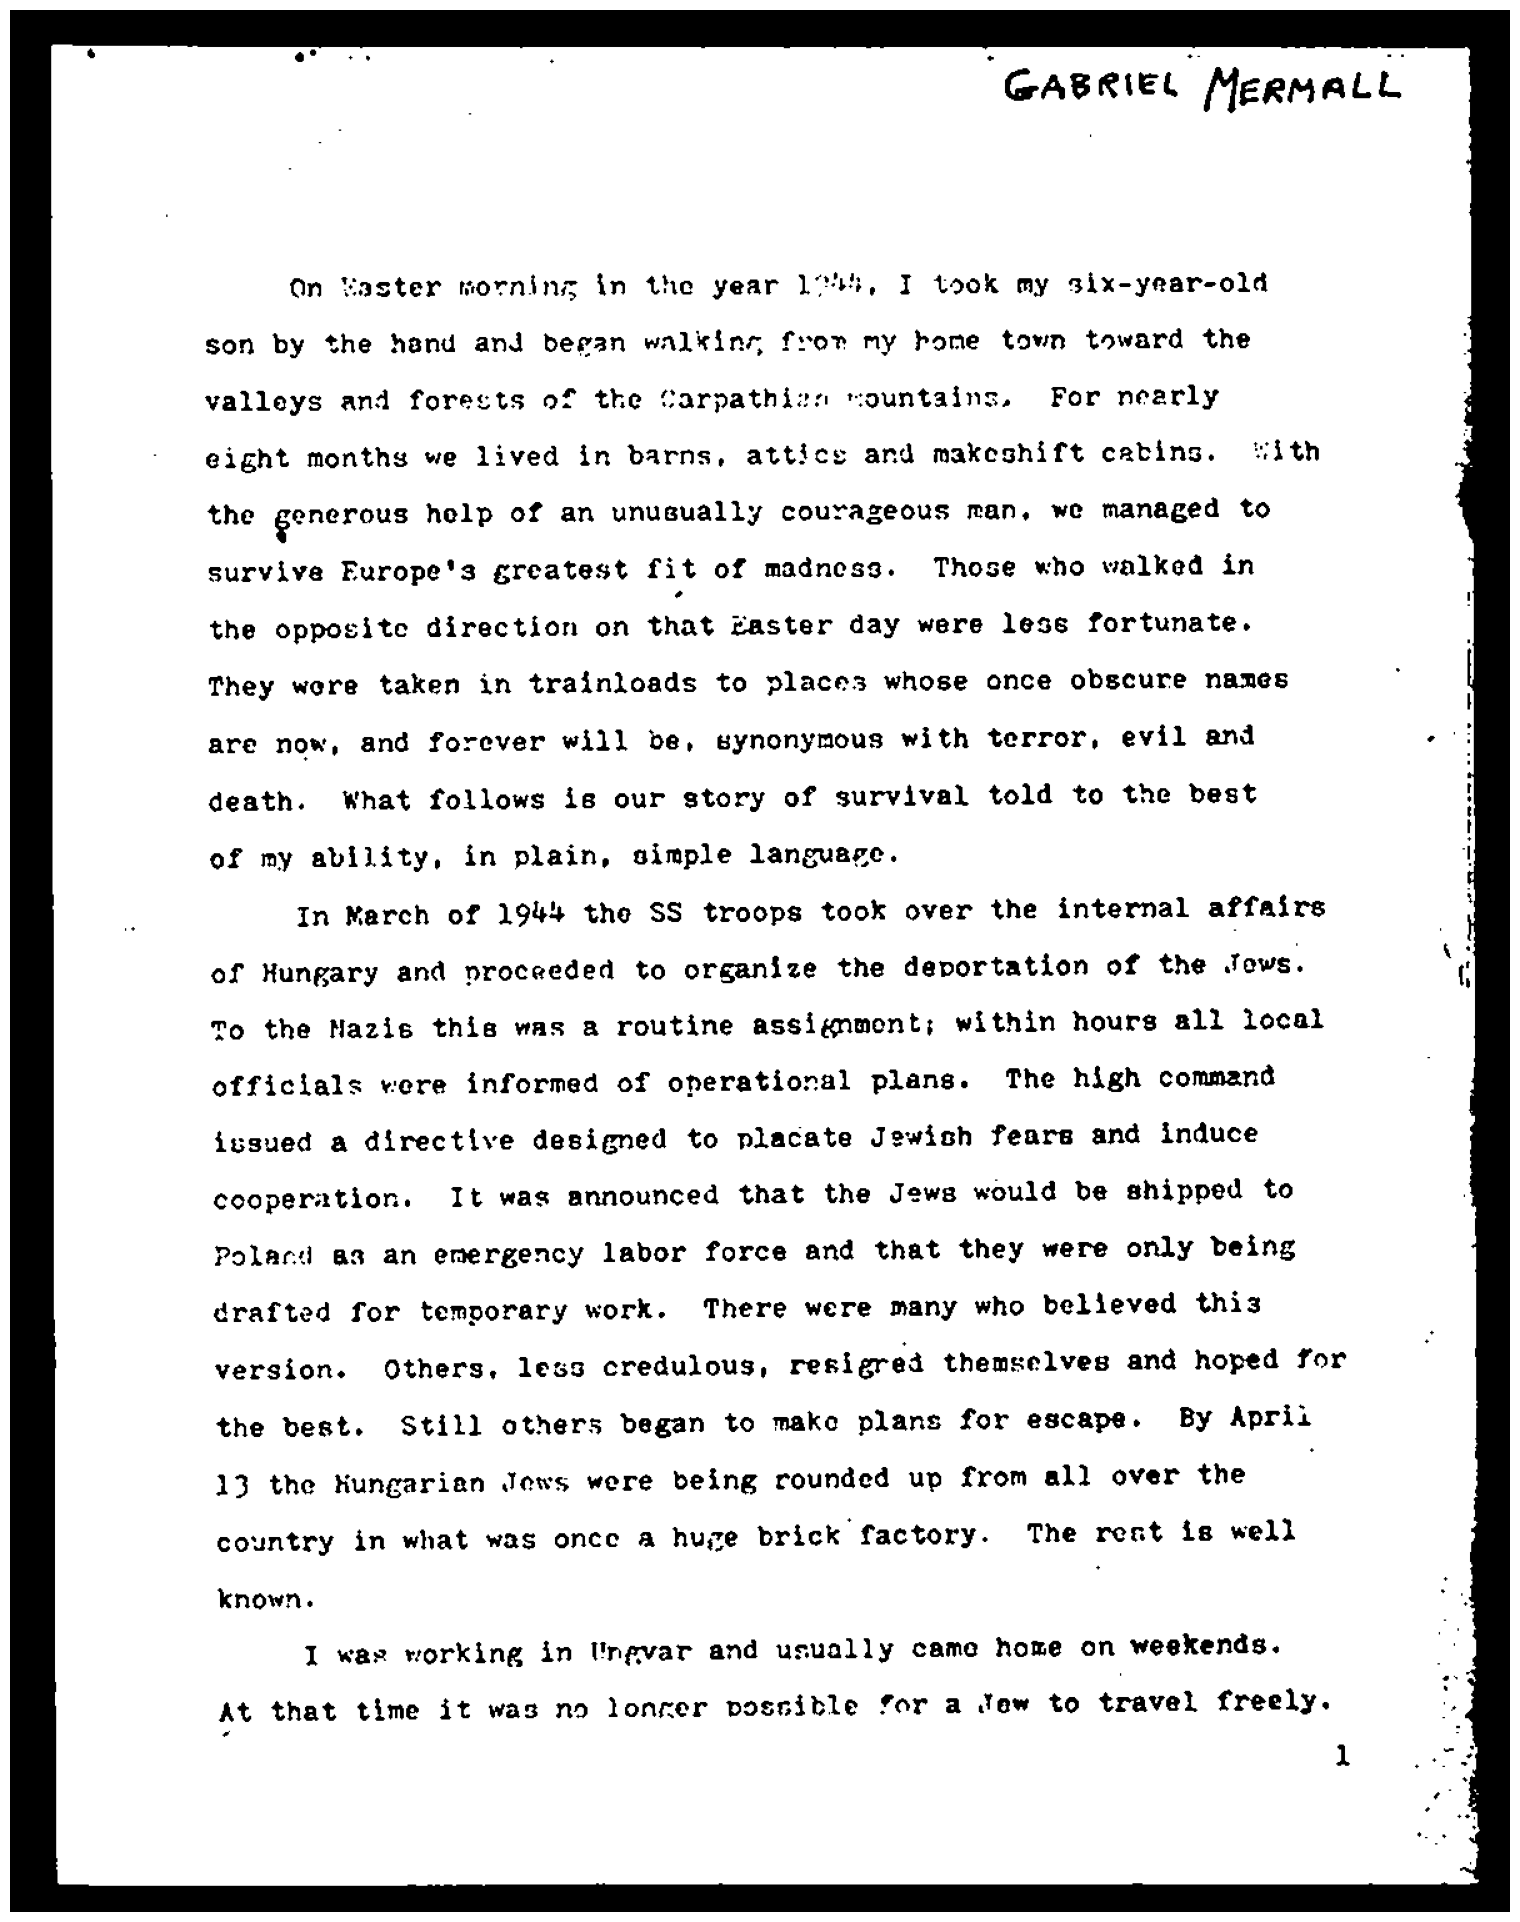

In [47]:
no_noise_img = nose_removal(img_bw)
cv.imwrite("../../data/process/test_no_noise.png", no_noise_img)
display("../../data/process/test_no_noise.png")

# Dilatação e Erosão

In [ ]:
def thin_font(image):
    #image = cv.bitwise_not(image)
    kernel = np.ones((2,2),np.uint8)
    image = cv.dilate(image, kernel, iterations = 1)
    #image = cv.bitwise_not(image)
    return image

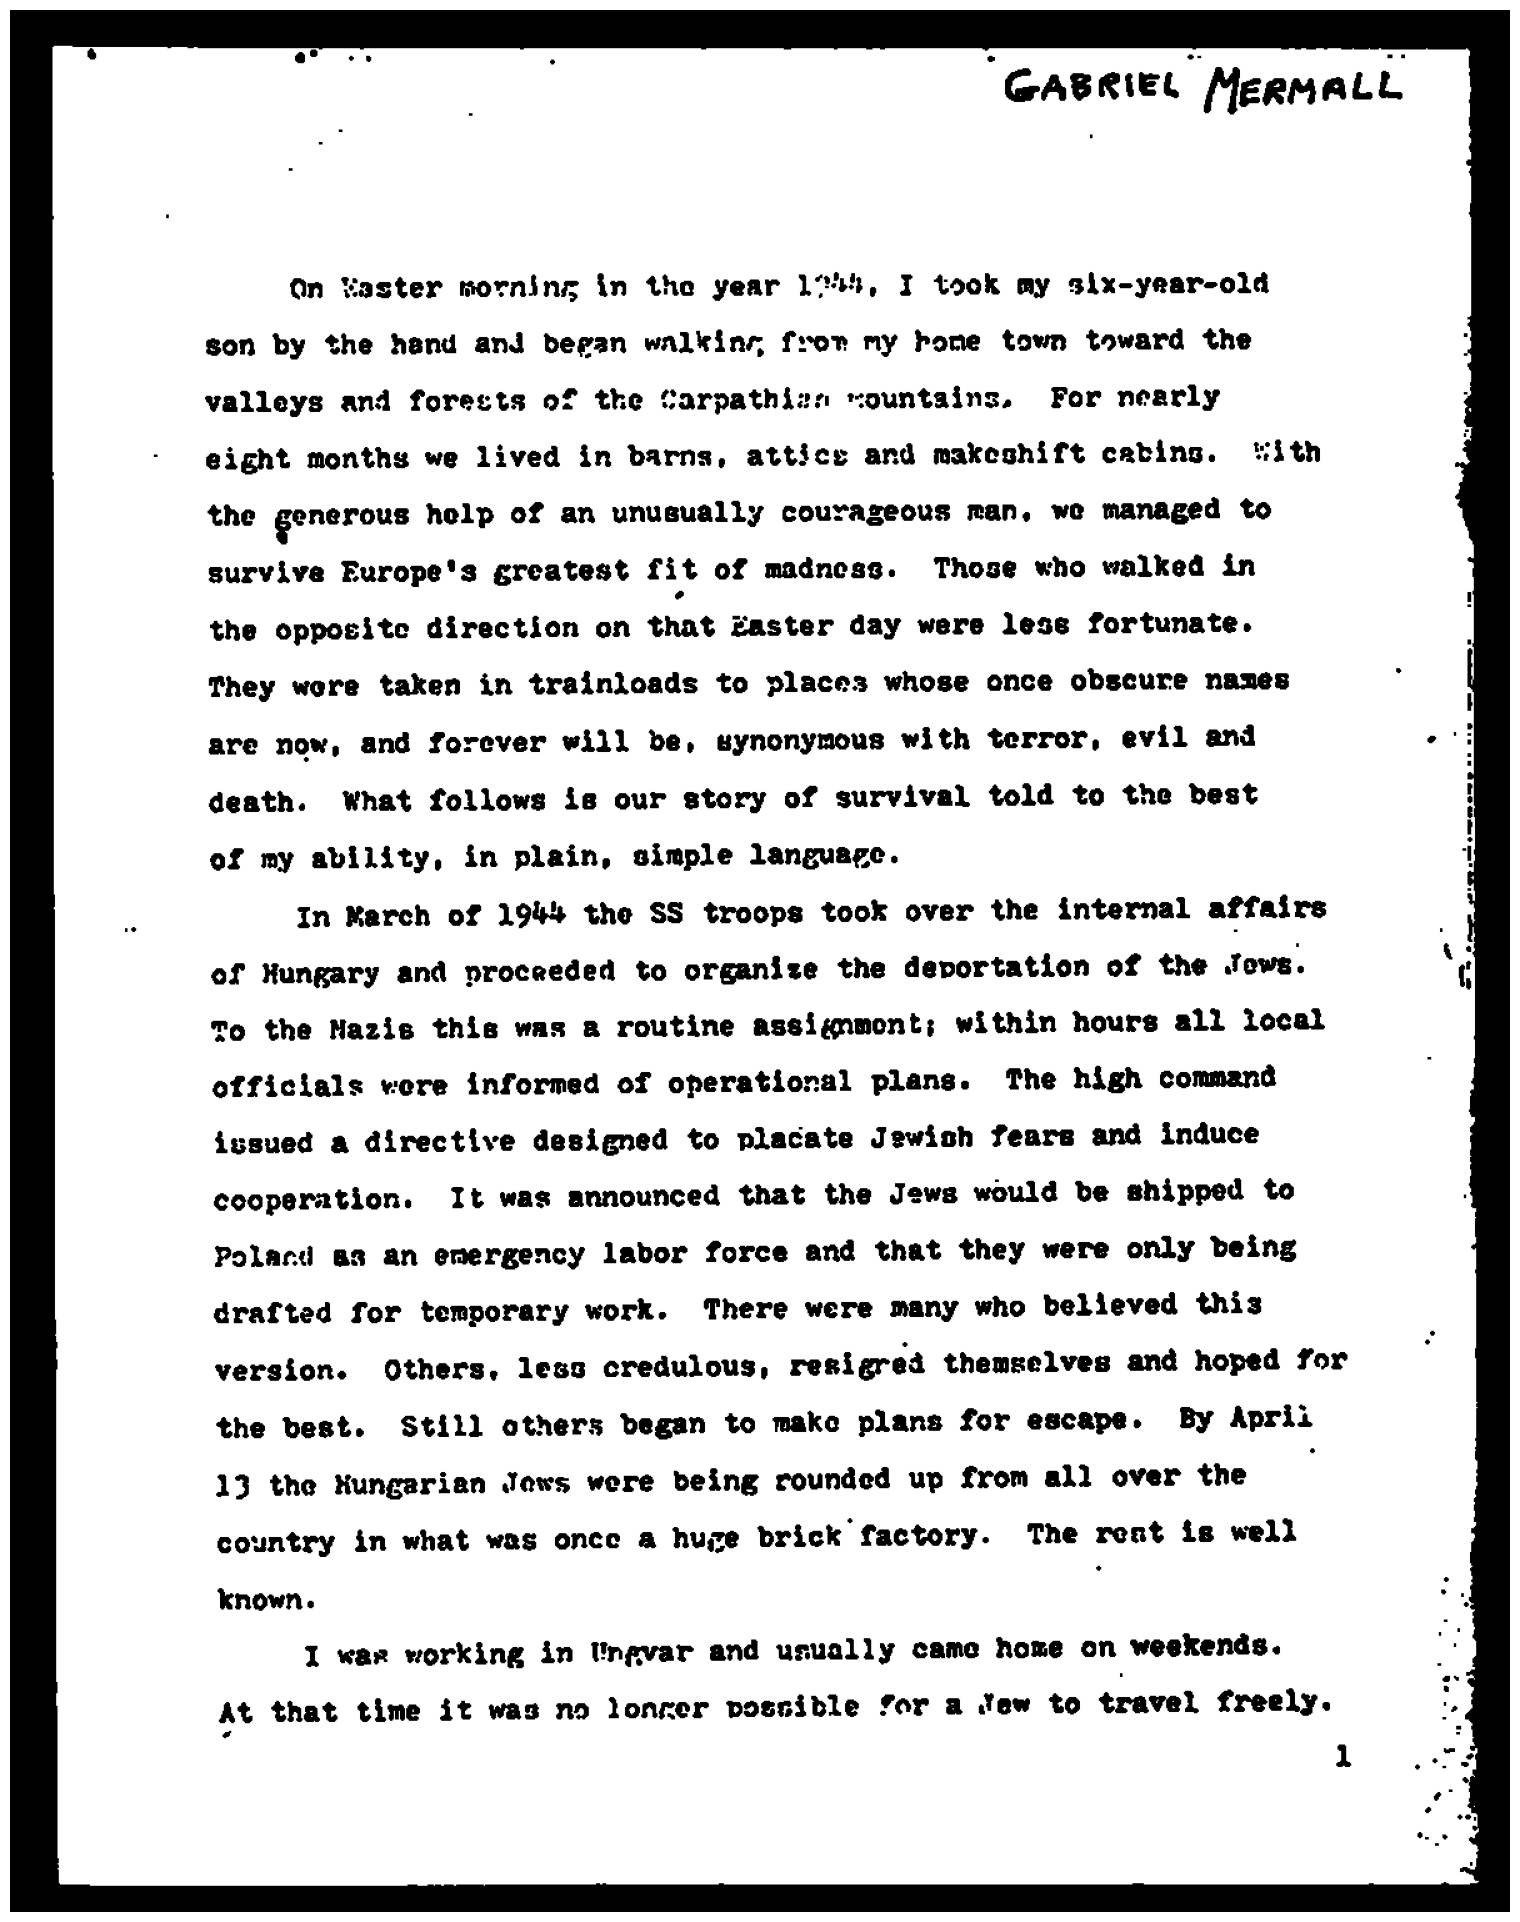

In [78]:
eroded_img = thin_font(no_noise_img)
cv.imwrite("../../data/process/test_dilated.png", eroded_img)
display("../../data/process/test_dilated.png")